In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_bank = Path("/content/drive/Shareddrives/Project Data Mining_Kelompok 4/DATASET/bank+marketing/bank-additional/bank-additional/bank-additional-full.csv")
data_bank = pd.read_csv(data_bank, sep=';')
data_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


prepocessing


In [ ]:
data_bank.isnull().sum()
data_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
data_bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
print(data_bank['y'].value_counts())
print(data_bank['y'].value_counts(normalize=True) * 100)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [ ]:
# Ganti 'unknown' dengan NaN
df= data_bank.copy()
df.replace('unknown', np.nan, inplace=True)

# Isi dengan modus
for col in df.columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [ ]:
#FEATURE SELECTION
df.drop('duration', axis=1, inplace=True)
df['y'] = df['y'].map({'yes': 1, 'no': 0})
print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


EDA


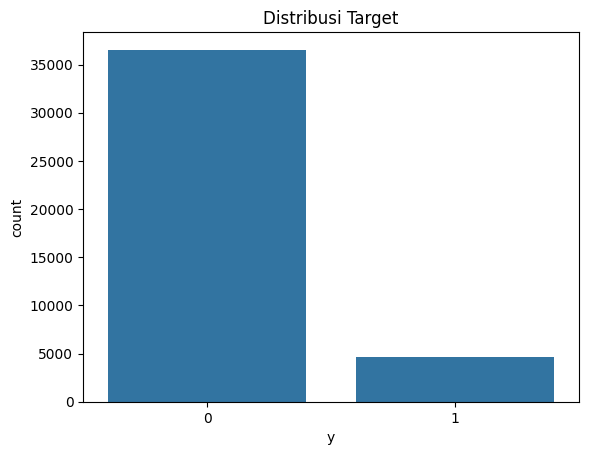

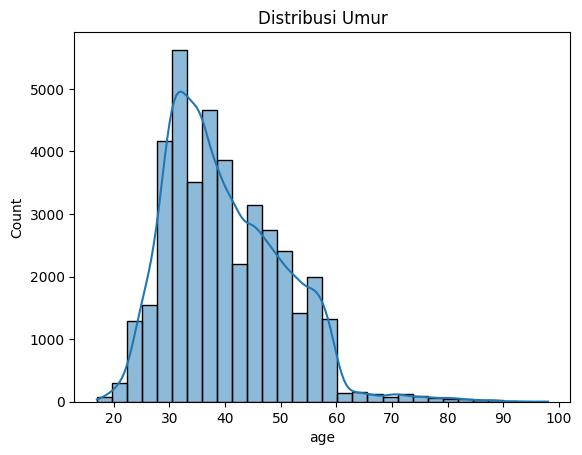

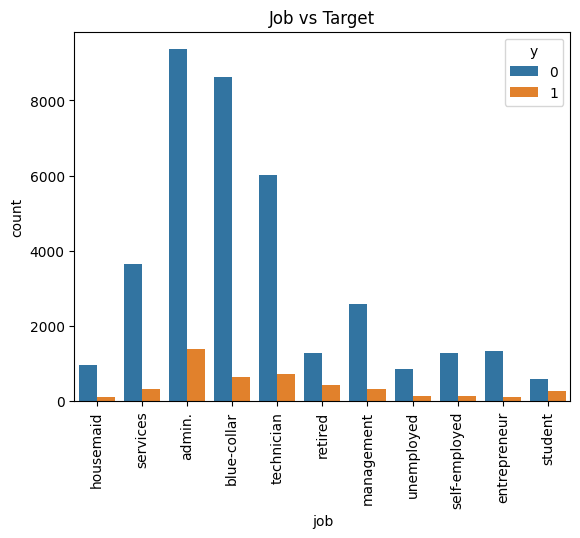

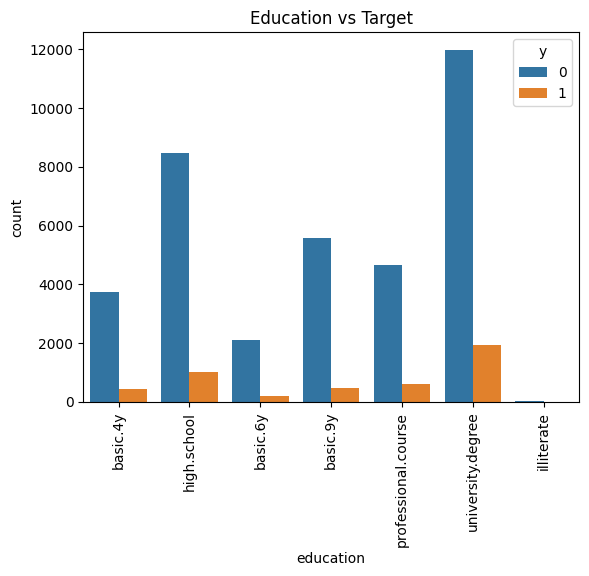

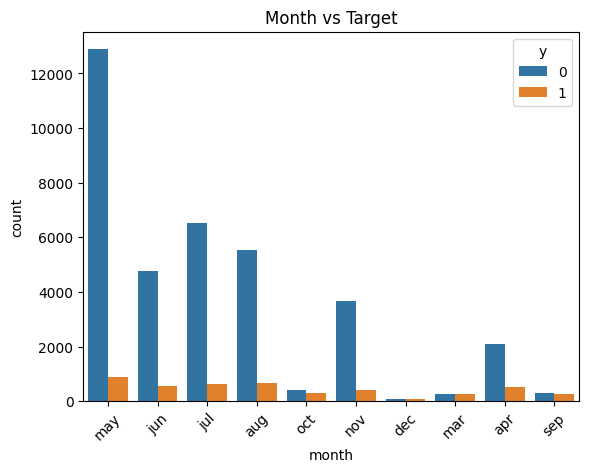

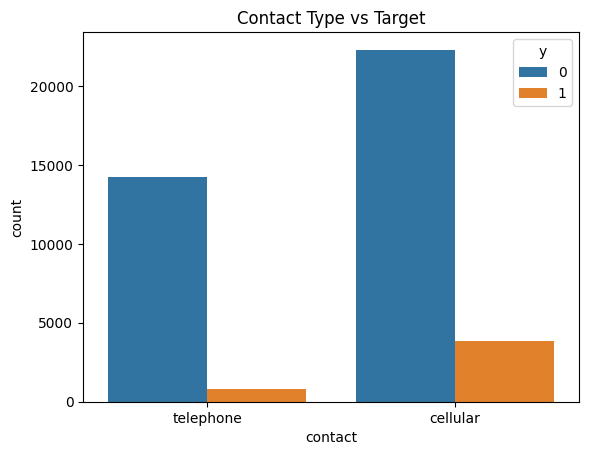

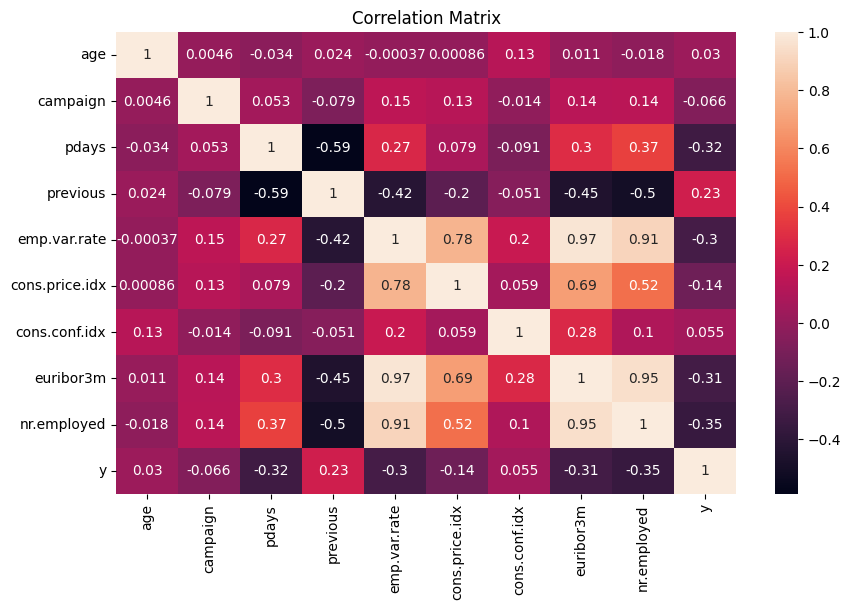

In [ ]:
sns.countplot(x='y', data=df)
plt.title('Distribusi Target')
plt.show()

sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribusi Umur')
plt.show()

sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.title('Job vs Target')
plt.show()

sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=90)
plt.title('Education vs Target')
plt.show()

sns.countplot(
    x='month',
    hue='y',
    data=df
)

plt.xticks(rotation=45)
plt.title('Month vs Target')
plt.show()

sns.countplot(
    x='contact',
    hue='y',
    data=df
)

plt.title('Contact Type vs Target')
plt.show()

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
X = df.drop('y', axis=1)
y = df['y']

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print("Sebelum SMOTE:")
print(y_train.value_counts())

Sebelum SMOTE:
y
0    29238
1     3712
Name: count, dtype: int64


In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_prep, y_train)

In [ ]:
print("Setelah SMOTE:")
print(y_train_sm.value_counts())

Setelah SMOTE:
y
0    29238
1    29238
Name: count, dtype: int64


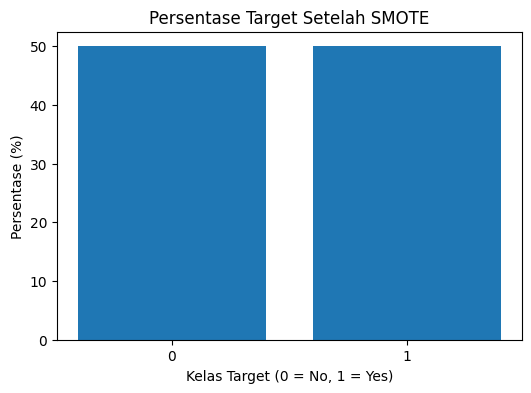

In [ ]:
percent = y_train_sm.value_counts(normalize=True) * 100
plt.figure(figsize=(6,4))
plt.bar(percent.index, percent.values)
plt.title('Persentase Target Setelah SMOTE')
plt.xlabel('Kelas Target (0 = No, 1 = Yes)')
plt.ylabel('Persentase (%)')
plt.xticks([0,1])
plt.show()

In [ ]:
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        )
}

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_prep)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
Accuracy: 0.8279922311240593
Confusion Matrix:
 [[6215 1095]
 [ 322  606]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238


===== Random Forest =====
Accuracy: 0.8764263170672494
Confusion Matrix:
 [[6662  648]
 [ 370  558]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.60      0.52       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.88      8238


===== KNN =====
Accuracy: 0.7369507161932508
Confusion Matrix:
 [[5462 1848]
 [ 319  609]]
              precision    recall  f1-score 

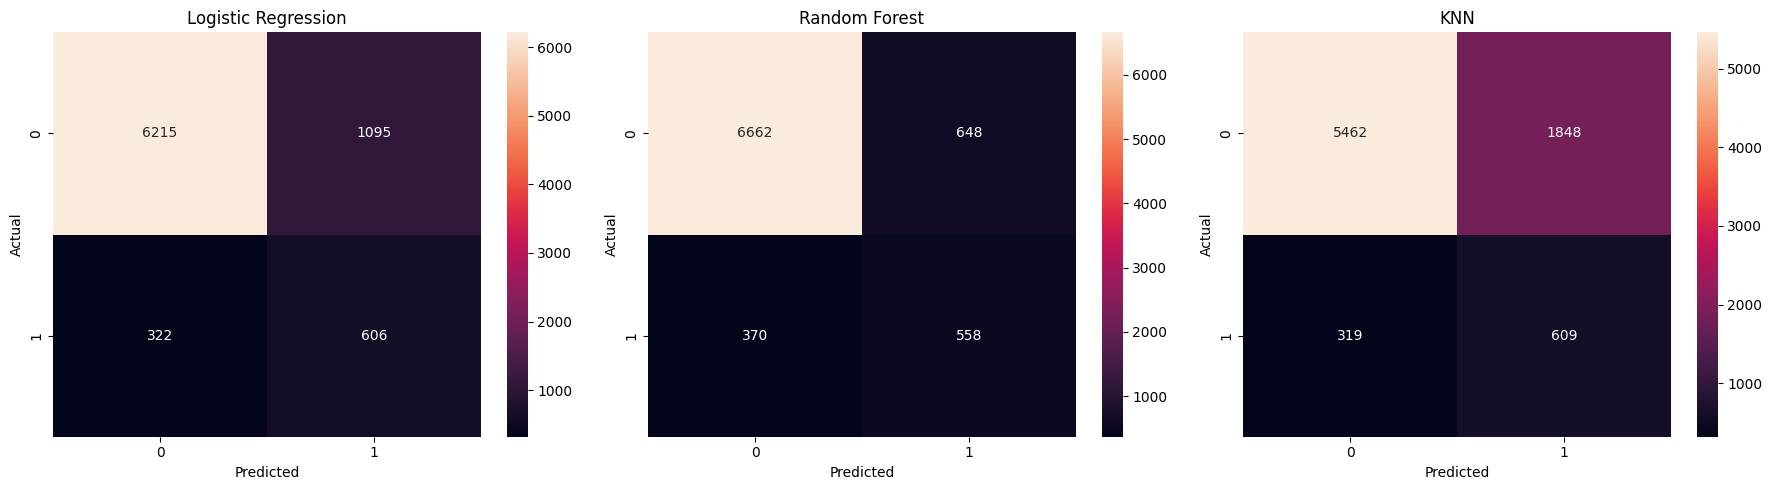

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, model) in zip(axes, models.items()):

    # Training
    model.fit(X_train_sm, y_train_sm)

    # Prediksi
    y_pred = model.predict(X_test_prep)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_prep)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_yes': report['1']['precision'],
        'Recall_yes': report['1']['recall'],
        'F1_yes': report['1']['f1-score']
    })

# Buat tabel hasil
results_df = pd.DataFrame(results)

# Urutkan berdasarkan F1-score kelas yes (terpenting)
results_df = results_df.sort_values(by='F1_yes', ascending=False)

results_df

,Model,Accuracy,Precision_yes,Recall_yes,F1_yes
1,Random Forest,0.876426,0.462687,0.601293,0.522962
0,Logistic Regression,0.827992,0.356261,0.653017,0.461012
2,KNN,0.736951,0.247863,0.656250,0.359823


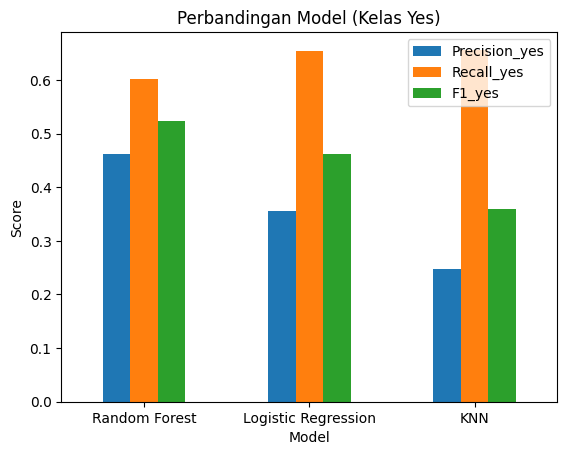

In [ ]:
results_df.set_index('Model')[
    ['Precision_yes',
     'Recall_yes',
     'F1_yes']
].plot(kind='bar')

plt.title(
    'Perbandingan Model (Kelas Yes)'
)

plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

num__euribor3m            0.157680
num__nr.employed          0.128005
num__emp.var.rate         0.099345
num__campaign             0.070417
num__cons.conf.idx        0.055009
cat__contact_telephone    0.051323
num__pdays                0.044890
cat__housing_yes          0.039504
num__cons.price.idx       0.038886
cat__month_may            0.036131
dtype: float64


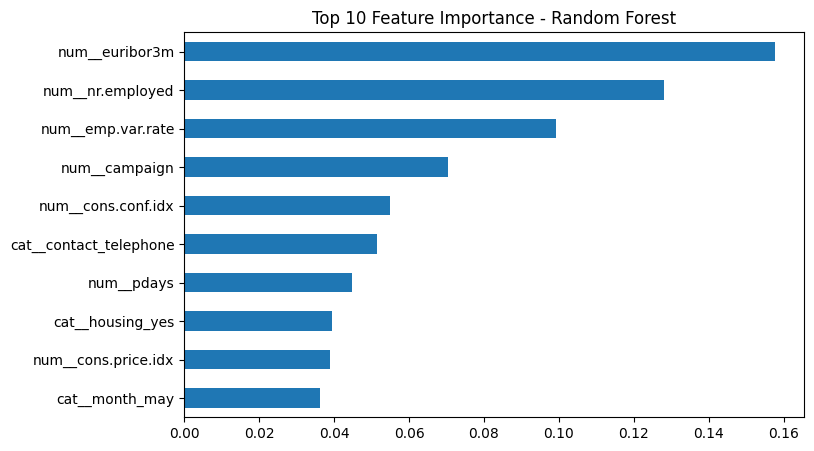

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# TRAIN MODEL DULU
rf.fit(X_train_sm, y_train_sm)

# Ambil nama fitur
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importances = rf.feature_importances_

feat_imp = pd.Series(
    importances,
    index=feature_names
)

# Ambil top 10 fitur
top_features = feat_imp.sort_values(
    ascending=False
).head(10)

print(top_features)

# Visualisasi
plt.figure(figsize=(8,5))

top_features.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Feature Importance - Random Forest'
)

plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Model Terbaik:")
print(best_model)

Model Terbaik:
Model            Random Forest
Accuracy              0.876426
Precision_yes         0.462687
Recall_yes            0.601293
F1_yes                0.522962
Name: 1, dtype: object


In [ ]:
top_features = feat_imp.sort_values(
    ascending=False
).head(10)

print(top_features)

num__euribor3m            0.157680
num__nr.employed          0.128005
num__emp.var.rate         0.099345
num__campaign             0.070417
num__cons.conf.idx        0.055009
cat__contact_telephone    0.051323
num__pdays                0.044890
cat__housing_yes          0.039504
num__cons.price.idx       0.038886
cat__month_may            0.036131
dtype: float64


In [ ]:
# KESIMPULAN OTOMATIS

best_model = results_df.iloc[0]

best_model_name = best_model['Model']
best_accuracy = best_model['Accuracy']
best_precision = best_model['Precision_yes']
best_recall = best_model['Recall_yes']
best_f1 = best_model['F1_yes']

# Ambil 3 fitur terpenting
top_3_features = top_features.index[:3]

print("\n===== KESIMPULAN PROJECT =====")

print(
    f"Model terbaik pada penelitian ini "
    f"adalah {best_model_name}, "
    f"karena memiliki nilai F1-score "
    f"kelas yes tertinggi sebesar "
    f"{best_f1:.4f}."
)

print(
    f"Model tersebut memperoleh "
    f"accuracy sebesar "
    f"{best_accuracy:.4f}, "
    f"precision sebesar "
    f"{best_precision:.4f}, "
    f"dan recall sebesar "
    f"{best_recall:.4f}."
)

print(
    "Hasil penelitian menunjukkan "
    "bahwa machine learning dapat "
    "digunakan untuk memprediksi "
    "keberhasilan kampanye marketing bank."
)

print(
    f"Fitur yang paling berpengaruh "
    f"terhadap prediksi deposito "
    f"berdasarkan Random Forest adalah: "
    f"{top_3_features[0]}, "
    f"{top_3_features[1]}, "
    f"dan {top_3_features[2]}."
)

print(
    f"Model {best_model_name} "
    "berpotensi membantu bank "
    "menentukan target nasabah "
    "yang lebih potensial sehingga "
    "strategi marketing menjadi "
    "lebih efektif."
)


===== KESIMPULAN PROJECT =====
Model terbaik pada penelitian ini adalah Random Forest, karena memiliki nilai F1-score kelas yes tertinggi sebesar 0.5230.
Model tersebut memperoleh accuracy sebesar 0.8764, precision sebesar 0.4627, dan recall sebesar 0.6013.
Hasil penelitian menunjukkan bahwa machine learning dapat digunakan untuk memprediksi keberhasilan kampanye marketing bank.
Fitur yang paling berpengaruh terhadap prediksi deposito berdasarkan Random Forest adalah: num__euribor3m, num__nr.employed, dan num__emp.var.rate.
Model Random Forest berpotensi membantu bank menentukan target nasabah yang lebih potensial sehingga strategi marketing menjadi lebih efektif.


Referensi:
1. https://github.com/ashutoshmakone/Bank-Marketing-Dataset-Machine-Learning/blob/main/README.md
2. https://www.kaggle.com/code/yufengsui/ml-project-bank-telemarketing-analysis
3. https://www.kaggle.com/code/gatewj/bank-marketing-dataset
4. https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset
5. https://link.springer.com/article/10.1007/s10994-020-05913-4
6. https://link.springer.com/article/10.1186/s40537-025-01313-4